In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages
library(readr)
library(readxl)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "superstore-sales-dataset"

# `Exploratory Data Analysis of Superstore Sales Dataset`

In [2]:
# read data
superstore <- read_excel("/kaggle/input/superstore-sales-dataset/superstore.xls",
                        col_types = c(rep("guess", 11), 
                                      "text",            
                                      rep("guess", 9)))
head(superstore)

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,⋯,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
<dbl>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,⋯,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,⋯,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,⋯,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,⋯,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,⋯,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,⋯,90032,West,FUR-FU-10001487,Furniture,Furnishings,"Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood",48.8600,7,0.00,14.1694


## Initial Data Exploration

In [3]:
# columns
colnames(superstore)

[1] "Row ID"        "Order ID"      "Order Date"    "Ship Date"    
 [5] "Ship Mode"     "Customer ID"   "Customer Name" "Segment"      
 [9] "Country"       "City"          "State"         "Postal Code"  
[13] "Region"        "Product ID"    "Category"      "Sub-Category" 
[17] "Product Name"  "Sales"         "Quantity"      "Discount"     
[21] "Profit"

In [4]:
# dimensions: (Rows, Columns)
dim(superstore)

[1] 9994   21

In [5]:
# Check date range
range(superstore$`Order Date`)

[1] "2014-01-03 UTC" "2017-12-30 UTC"

In [6]:
# info
str(superstore)

tibble [9,994 × 21] (S3: tbl_df/tbl/data.frame)
 $ Row ID       : num [1:9994] 1 2 3 4 5 6 7 8 9 10 ...
 $ Order ID     : chr [1:9994] "CA-2016-152156" "CA-2016-152156" "CA-2016-138688" "US-2015-108966" ...
 $ Order Date   : POSIXct[1:9994], format: "2016-11-08" "2016-11-08" ...
 $ Ship Date    : POSIXct[1:9994], format: "2016-11-11" "2016-11-11" ...
 $ Ship Mode    : chr [1:9994] "Second Class" "Second Class" "Second Class" "Standard Class" ...
 $ Customer ID  : chr [1:9994] "CG-12520" "CG-12520" "DV-13045" "SO-20335" ...
 $ Customer Name: chr [1:9994] "Claire Gute" "Claire Gute" "Darrin Van Huff" "Sean O'Donnell" ...
 $ Segment      : chr [1:9994] "Consumer" "Consumer" "Corporate" "Consumer" ...
 $ Country      : chr [1:9994] "United States" "United States" "United States" "United States" ...
 $ City         : chr [1:9994] "Henderson" "Henderson" "Los Angeles" "Fort Lauderdale" ...
 $ State        : chr [1:9994] "Kentucky" "Kentucky" "California" "Florida" ...
 $ Postal Code  : chr [

In [7]:
# missing values?
colSums(is.na(superstore))

Row ID      Order ID    Order Date     Ship Date     Ship Mode 
            0             0             0             0             0 
  Customer ID Customer Name       Segment       Country          City 
            0             0             0             0             0 
        State   Postal Code        Region    Product ID      Category 
            0             0             0             0             0 
 Sub-Category  Product Name         Sales      Quantity      Discount 
            0             0             0             0             0 
       Profit 
            0

In [8]:
# duplicates?
sum(duplicated(superstore))

[1] 0

In [9]:
# summary statistics
summary(superstore)

     Row ID       Order ID           Order Date                    
 Min.   :   1   Length:9994        Min.   :2014-01-03 00:00:00.00  
 1st Qu.:2499   Class :character   1st Qu.:2015-05-23 00:00:00.00  
 Median :4998   Mode  :character   Median :2016-06-26 00:00:00.00  
 Mean   :4998                      Mean   :2016-04-30 00:07:12.25  
 3rd Qu.:7496                      3rd Qu.:2017-05-14 00:00:00.00  
 Max.   :9994                      Max.   :2017-12-30 00:00:00.00  
   Ship Date                       Ship Mode         Customer ID       
 Min.   :2014-01-07 00:00:00.00   Length:9994        Length:9994       
 1st Qu.:2015-05-27 00:00:00.00   Class :character   Class :character  
 Median :2016-06-29 00:00:00.00   Mode  :character   Mode  :character  
 Mean   :2016-05-03 23:06:58.56                                        
 3rd Qu.:2017-05-18 00:00:00.00                                        
 Max.   :2018-01-05 00:00:00.00                                        
 Customer Name      

In [10]:
# unique customer counts
n_distinct(superstore$`Customer ID`)

[1] 793

In [11]:
# unique product count
n_distinct(superstore$`Product ID`)

[1] 1862

In [12]:
# States
n_distinct(superstore$State)

[1] 49

### Observations:
- Clean data with no missing and duplicate values
- `Sales`
  - **Range:** From **\$0.44** (minimum) to **\$22,638.48** (maximum).
  - **Central Tendency:** The **mean** is **\$229.858** and the **median** is **\$54.490**.
    - *Note:* The large difference between the mean and median indicates a high positive skew, where a few huge orders are significantly pulling up the average.
- `Profit`
  - **Range:** From a minimum loss of **-\$6,599.978** to a maximum gain of **+\$8,399.976**.
  - Some orders lose money!!
- `Discount`
  - **Range:** From minimum of **0%** to maximum **80%**, indicating heavy discounting.
  - **Central Tendency:** The **mean** (average) discount applied is **15.6%**.

## Univariate Analysis

In [13]:
# customer segments
table(superstore$Segment)


   Consumer   Corporate Home Office 
       5191        3020        1783 

In [14]:
# Regions
table(superstore$Region)


Central    East   South    West 
   2323    2848    1620    3203 

In [15]:
# Categories
table(superstore$Category)


      Furniture Office Supplies      Technology 
           2121            6026            1847 

In [16]:
# ship mode
table(superstore$`Ship Mode`)


   First Class       Same Day   Second Class Standard Class 
          1538            543           1945           5968 

In [17]:
# Sub-category
table(superstore$`Sub-Category`)


Accessories  Appliances         Art     Binders   Bookcases      Chairs 
        775         466         796        1523         228         617 
    Copiers   Envelopes   Fasteners Furnishings      Labels    Machines 
         68         254         217         957         364         115 
      Paper      Phones     Storage    Supplies      Tables 
       1370         889         846         190         319 

### Observations
`Customer Segment`
-   Consumer: 5191 (~52%) - Largest segment of customers
-   Corporate: 3020 (30.2%)
-   Home Office: 1783 (17.8%) - Smallest

`Product Categories`
- Office Supplies: 6026 - Most orders
- Furniture: 2121
- Technology: 1847

`Region`
- West: 3203 - Highest
- Central: 2323
- East: 2848
- South: 1620

`Ship Mdde`
- Standard Class: 5968 - Most Common
- First Class: 1538
- Second Class: 1945
- Same Day: 534

`Sub-Category`
- Binders: 1523 (15.2%)
- ....
- ....
- Copiers: 68 (0.68%)
                        

## Bivariate Analysis

**We observed that there was negative profit and also that there was heavy discounting as well, so let's see if discount affected profits?**

In [18]:
discount_summary <- superstore %>%
mutate(
    Discount_Level = case_when(
        Discount == 0 ~ "No Discount",
        Discount > 0 & Discount <= 0.2 ~ "Low (1-20%)",
        Discount > 0.2 & Discount <= 0.4 ~ "Medium (21-40%)",
        Discount > 0.4 ~ "High Discount (40%+)",
        TRUE ~ "Other" # catch remaining cases
    )
) %>%
group_by(Discount_Level) %>%
summarise(
    count=n(),
    avg_sales = mean(Sales),
    avg_profit = mean(Profit),
    total_profit = sum(Profit),
    avg_negative_profit = sum(Profit<0)
) %>%
arrange(desc(avg_negative_profit))

In [19]:
discount_summary

Discount_Level,count,avg_sales,avg_profit,total_profit,avg_negative_profit
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
High Discount (40%+),933,137.8695,-106.70803,-99558.59,933
Low (1-20%),3803,222.5933,26.50157,100785.47,523
Medium (21-40%),460,508.9954,-77.86406,-35817.47,415
No Discount,4798,226.7421,66.90029,320987.60,0


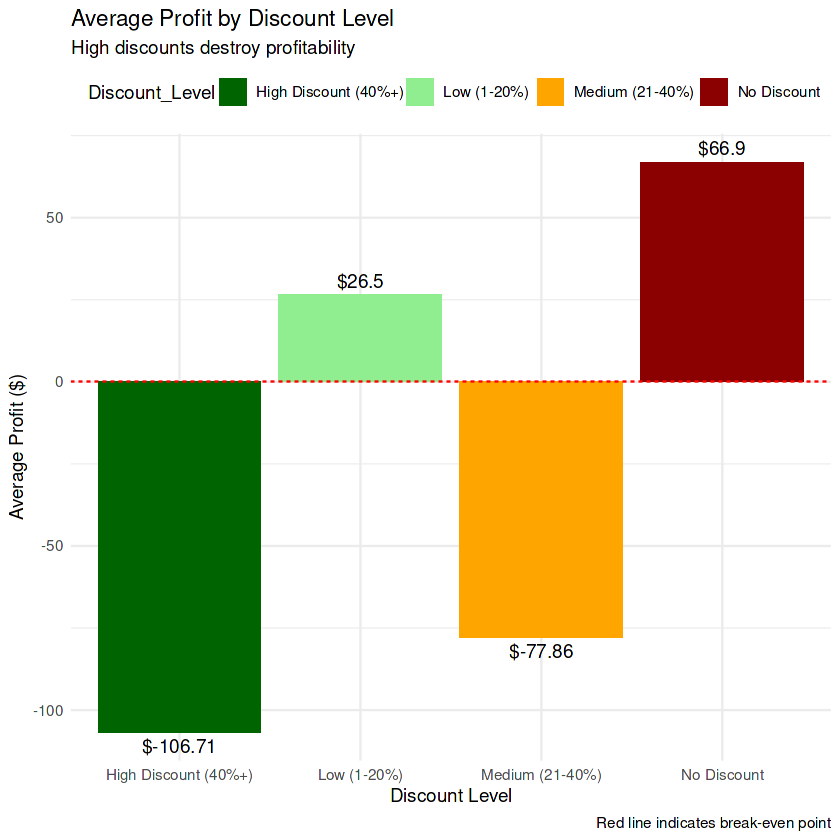

In [20]:
# Visualising: Average Profit by Discount level
ggplot(discount_summary, aes(x = Discount_Level, y = avg_profit, fill = Discount_Level)) +
  geom_col() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  scale_fill_manual(values = c("darkgreen", "lightgreen", "orange", "darkred")) +
  labs(
    title = "Average Profit by Discount Level",
    subtitle = "High discounts destroy profitability",
    x = "Discount Level",
    y = "Average Profit ($)",
    caption = "Red line indicates break-even point"
  ) +
  theme_minimal() +
  theme(legend.position = "top") +
  geom_text(aes(label = paste0("$", round(avg_profit, 2))), 
            vjust = ifelse(discount_summary$avg_profit > 0, -0.5, 1.5))

#### Observation
- As the discount increases, we can see the profits decreasing


feat: Add univariate analysis and start bivariate analysis